In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from uniformity_fit import *
from flatness import *
from scipy.io import loadmat
from glob import glob
from YAG_RCF_analysis import *


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May  8 19:04:27 2026',
 '__version__': '1.0',
 '__globals__': ['newptchargeBCM_Gun',
  'newptchargeBCM_Vesper',
  'newptchargeBCM_THz',
  'newptchargeBCM_THz_2'],
 'newptchargeBCM_Gun': array([[0.38509462]]),
 'newptchargeBCM_Vesper': array([[0.02145563]]),
 'newptchargeBCM_THz': array([[0.15375939]]),
 'newptchargeBCM_THz_2': array([[0.07596935]])}

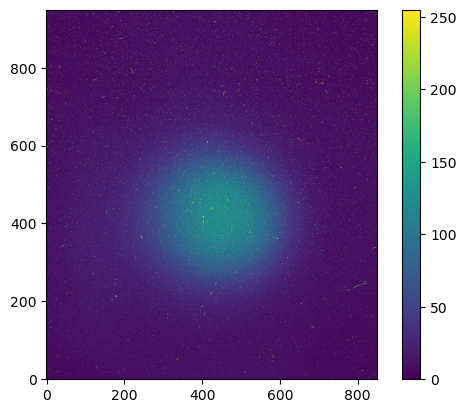

In [2]:
path = "CLEAR_experiments/May2026/PDD_YAG/large_orig/FLASH_single_85mm_col/"

file_num = 1
yag_data = loadmat(path + f"YAG_{file_num:02d}.mat")

cropping = (slice(150, 1100), slice(550, 1400))
yag_data
yag_data['image1'].shape
plt.imshow(yag_data['image1'][cropping], origin="lower")
plt.colorbar()
charge_data = loadmat(path + f"charge_{file_num:02d}.mat")
charge_data

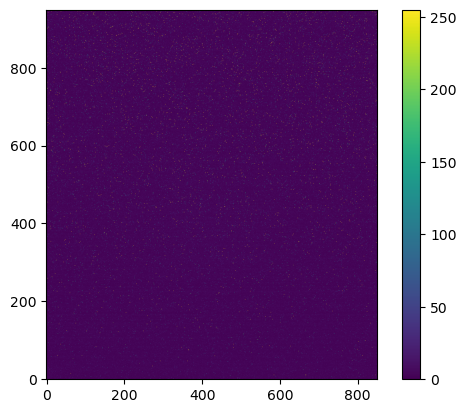

In [7]:
file_num = 8
background = loadmat(path + f"bgnd_YAG_{file_num:02d}.mat")
background_arr = np.array(background['image1_bgnd'][cropping])
plt.imshow(background_arr, origin="lower")
plt.colorbar()


In [8]:
file_num =1
bgnd_charge_data = loadmat(path + f"bgnd_Charge_{file_num:02d}.mat")
bgnd_charge_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May  8 19:04:45 2026',
 '__version__': '1.0',
 '__globals__': ['newptchargeBCM_Gun',
  'newptchargeBCM_Vesper',
  'newptchargeBCM_THz',
  'newptchargeBCM_THz_2'],
 'newptchargeBCM_Gun': array([[0.00771117]]),
 'newptchargeBCM_Vesper': array([[0.02138423]]),
 'newptchargeBCM_THz': array([[0.00521218]]),
 'newptchargeBCM_THz_2': array([[0.01849254]])}

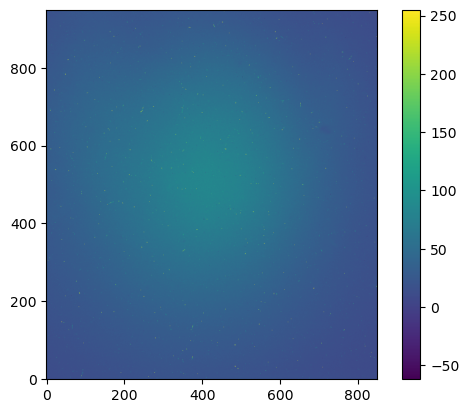

In [15]:
plt.imshow(yag_data['image1'][cropping]-background_arr, origin="lower")
plt.colorbar()

In [3]:
files = sorted(glob(path + "YAG_*.mat"))
images = []

for file in files:
    data = loadmat(file)
    img = data["image1"][cropping]
    images.append(img)

avg_image = np.mean(images, axis=0)

plot_dose1(avg_image-background_arr, 'YAG')

NameError: name 'path' is not defined

Skipping YAG_01: background charge (0.477942 pC) is > 20% of raw charge (0.458045 pC)
YAG_02
Charge file Q     = 0.422002 pC
Map integrated Q  = 0.422002 pC
Difference        = 0 pC
Relative error    = 0.000e+00
YAG_03
Charge file Q     = 0.429823 pC
Map integrated Q  = 0.429823 pC
Difference        = -1.11022e-16 pC
Relative error    = -2.583e-16
YAG_04
Charge file Q     = 0.467102 pC
Map integrated Q  = 0.467102 pC
Difference        = -5.55112e-17 pC
Relative error    = -1.188e-16
YAG_05
Charge file Q     = 0.457405 pC
Map integrated Q  = 0.457405 pC
Difference        = -1.11022e-16 pC
Relative error    = -2.427e-16
Skipping YAG_07: missing bgnd_YAG_07.mat
YAG_08
Charge file Q     = 0.414958 pC
Map integrated Q  = 0.414958 pC
Difference        = -5.55112e-17 pC
Relative error    = -1.338e-16
YAG_09
Charge file Q     = 0.424106 pC
Map integrated Q  = 0.424106 pC
Difference        = 1.11022e-16 pC
Relative error    = 2.618e-16
Skipping YAG_10: missing bgnd_YAG_10.mat


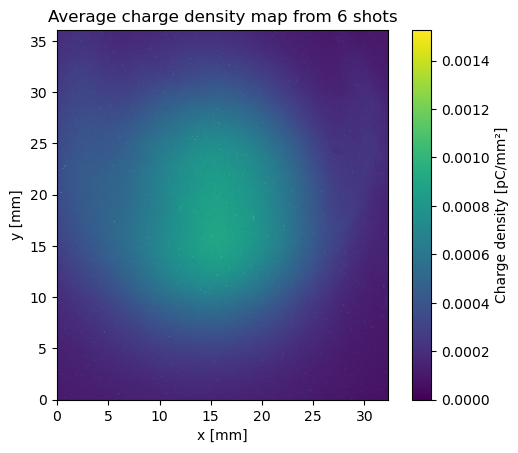

In [4]:
#inspecting charge densities and charges
import os, re
mm_per_pixel = 0.038
pixel_area_mm2 = mm_per_pixel**2

yag_files = sorted(glob(os.path.join(path, "YAG_*.mat")))

density_maps = []
charges_pC = []
file_nums_used = []

for yag_file in yag_files:
    filename = os.path.basename(yag_file)

    match = re.search(r"YAG_(\d+)\.mat", filename) #extract file number
    if match is None:
        print(f"Skipping {filename}: could not extract file number")
        continue

    file_num = int(match.group(1)) #get file number as int

    bgnd_yag_file = os.path.join(path, f"bgnd_YAG_{file_num:02d}.mat")
    charge_file = os.path.join(path, f"Charge_{file_num:02d}.mat")
    bgnd_charge_file = os.path.join(path, f"bgnd_Charge_{file_num:02d}.mat")

    if not os.path.exists(bgnd_yag_file):
        print(f"Skipping YAG_{file_num:02d}: missing {os.path.basename(bgnd_yag_file)}")
        continue

    if not os.path.exists(charge_file):
        print(f"Skipping YAG_{file_num:02d}: missing {os.path.basename(charge_file)}")
        continue

    if not os.path.exists(bgnd_charge_file):
        print(f"Skipping YAG_{file_num:02d}: missing {os.path.basename(bgnd_charge_file)}")
        continue

    yag_data = loadmat(yag_file)
    bgnd_yag_data = loadmat(bgnd_yag_file)
    charge_data = loadmat(charge_file)
    bgnd_charge_data = loadmat(bgnd_charge_file)

    image = np.array(yag_data["image1"][cropping], dtype=float)
    background_arr = np.array(bgnd_yag_data["image1_bgnd"][cropping], dtype=float)

    image_bgsub = image - background_arr
    image_bgsub[image_bgsub < 0] = 0

    total_signal = np.sum(image_bgsub)
    

    if total_signal <= 0:
        print(f"Skipping YAG_{file_num:02d}: total YAG signal is zero or negative")
        continue

    Q_raw = np.squeeze(charge_data['newptchargeBCM_THz_2'])
    Q_bgnd = np.squeeze(bgnd_charge_data['newptchargeBCM_THz_2'])
    if abs(Q_bgnd) > 0.2 * abs(Q_raw):
        print(
            f"Skipping YAG_{file_num:02d}: background charge ({Q_bgnd:.6g} pC) is > 20% of raw charge ({Q_raw:.6g} pC)"
        )
        continue
    
    Q_pC = float(Q_raw - Q_bgnd)

    if Q_pC <= 0:
        print(f"Skipping YAG_{file_num:02d}: charge is zero or negative after background subtraction")
        continue

    charge_density = image_bgsub * Q_pC / total_signal / pixel_area_mm2


    Q_from_map_pC = np.sum(charge_density) * pixel_area_mm2

    print(f"YAG_{file_num:02d}")
    print(f"Charge file Q     = {Q_pC:.6g} pC")
    print(f"Map integrated Q  = {Q_from_map_pC:.6g} pC")
    print(f"Difference        = {Q_from_map_pC - Q_pC:.6g} pC")
    print(f"Relative error    = {(Q_from_map_pC - Q_pC) / Q_pC:.3e}")

    density_maps.append(charge_density)
    charges_pC.append(Q_pC)
    file_nums_used.append(file_num)

density_maps = np.array(density_maps)
charges_pC = np.array(charges_pC)

avg_charge_density = np.mean(density_maps, axis=0)

ny, nx = avg_charge_density.shape

x_mm = np.arange(nx) * mm_per_pixel
y_mm = np.arange(ny) * mm_per_pixel
extent = [x_mm[0], x_mm[-1],y_mm[0],y_mm[-1]]
plt.figure()
plt.imshow(avg_charge_density, origin="lower", extent=extent)
plt.colorbar(label="Charge density [pC/mm²]")
plt.title(f"Average charge density map from {len(density_maps)} shots")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.show()


In [2]:
from pathlib import Path
import csv

from scipy.io import loadmat
import traceback

input_dir = Path("CLEAR_experiments/May2026/PDD_YAG/small/")
csv_path = Path("CLEAR_experiments/May2026/PDD_YAG_small.csv")
fig_output_dir = Path("CLEAR_experiments/May2026/PDD_YAG_output_figs/small/")
fig_output_dir.mkdir(parents=True, exist_ok=True)

cropping = (slice(150, 1100), slice(550, 1400))

mm_per_pixel = 0.038
pixel_area_mm2 = mm_per_pixel**2

charge_key = "newptchargeBCM_THz_2"

done = set()

if csv_path.exists() and csv_path.stat().st_size > 0:
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)

        for row in reader:
            if len(row) >= 1:
                done.add(row[0])

write_header = not csv_path.exists() or csv_path.stat().st_size == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "folder", "cx", "cy", "CD_centre", "P_x", "P_y", "r90_x", "r90_y", "ratio_x", "ratio_y",
            "CD_std","errPx","errPy", "err_x90_x","err_x90_y", "charge_after_bgnd_pC"])

    for folder in sorted(input_dir.iterdir()):
        if not folder.is_dir():
            continue

        folder_name = folder.name

        if folder_name in done:
            print(f"Skipping already processed folder: {folder_name}")
            continue

        print(f"\nProcessing folder: {folder_name}")

        yag_files = sorted(folder.glob("YAG_*.mat"))
        bgnd_yag_files = sorted(folder.glob("bgnd_YAG_*.mat"))

        charge_files = sorted(folder.glob("Charge_*.mat"))
        bgnd_charge_files = sorted(folder.glob("bgnd_Charge_*.mat"))

        if len(yag_files) == 0:
            print(f"Skipping {folder_name}: no YAG_*.mat files found")
            continue

        if len(bgnd_yag_files) == 0:
            print(f"Skipping {folder_name}: no bgnd_YAG_*.mat files found")
            continue

        if len(charge_files) == 0:
            print(f"Skipping {folder_name}: no Charge_*.mat files found")
            continue

        if len(bgnd_charge_files) == 0:
            print(f"Skipping {folder_name}: no bgnd_Charge_*.mat files found")
            continue

        yag_images = []
        bgnd_yag_images = []

        yag_charges = []
        bgnd_charges = []

        # Load all YAG signal images
        for yag_file in yag_files:
            try:
                yag_data = loadmat(yag_file)
                image = np.array(yag_data["image1"][cropping], dtype=float)

                if not np.all(np.isfinite(image)):
                    print(f"Skipping {yag_file.name}: image contains NaN or inf")
                    continue

                yag_images.append(image)

            except Exception as e:
                print(f"Skipping {yag_file.name}: {e}")

        # Load all YAG background images
        for bgnd_yag_file in bgnd_yag_files:
            try:
                bgnd_yag_data = loadmat(bgnd_yag_file)
                bgnd_image = np.array(bgnd_yag_data["image1_bgnd"][cropping], dtype=float)

                if not np.all(np.isfinite(bgnd_image)):
                    print(f"Skipping {bgnd_yag_file.name}: background image contains NaN or inf")
                    continue

                bgnd_yag_images.append(bgnd_image)

            except Exception as e:
                print(f"Skipping {bgnd_yag_file.name}: {e}")

        # Load all charge values, skipping NaN/inf
        for charge_file in charge_files:
            try:
                charge_data = loadmat(charge_file)
                Q_raw = float(np.squeeze(charge_data[charge_key]))

                if not np.isfinite(Q_raw):
                    print(f"Skipping {charge_file.name}: charge is NaN or inf")
                    continue

                yag_charges.append(Q_raw)

            except Exception as e:
                print(f"Skipping {charge_file.name}: {e}")

        # Load all background charge values, skipping NaN/inf
        for bgnd_charge_file in bgnd_charge_files:
            try:
                bgnd_charge_data = loadmat(bgnd_charge_file)
                Q_bgnd = float(np.squeeze(bgnd_charge_data[charge_key]))

                if (not np.isfinite(Q_bgnd)) or abs(Q_bgnd) > 0.3 * max(1e-6, abs(Q_raw)):
                    print(f"Skipping {bgnd_charge_file.name}: background charge is NaN, inf or >30% of raw charge")
                    print(f"Q_bgnd = {Q_bgnd}, Q_raw = {Q_raw}")
                    continue

                bgnd_charges.append(Q_bgnd)

            except Exception as e:
                print(f"Skipping {bgnd_charge_file.name}: {e}")

        if len(yag_images) == 0:
            print(f"Skipping {folder_name}: no valid YAG images")
            continue

        if len(bgnd_yag_images) == 0:
            print(f"Skipping {folder_name}: no valid background YAG images")
            continue

        if len(yag_charges) == 0:
            print(f"Skipping {folder_name}: no valid charge files after removing NaN/inf")
            continue

        if len(bgnd_charges) == 0:
            print(f"Skipping {folder_name}: no valid background charge files after removing NaN/inf")
            continue

        yag_images = np.array(yag_images)
        bgnd_yag_images = np.array(bgnd_yag_images)

        mean_yag = np.mean(yag_images, axis=0)
        mean_bgnd_yag = np.mean(bgnd_yag_images, axis=0)

        image_bgsub = mean_yag - mean_bgnd_yag
        image_bgsub[image_bgsub < 0] = 0

        total_signal = np.sum(image_bgsub)

        yag_charges = np.array(yag_charges, dtype=float)
        bgnd_charges = np.array(bgnd_charges, dtype=float)

        mean_yag_charge_pC = np.mean(yag_charges)
        mean_bgnd_charge_pC = np.mean(bgnd_charges)

        Q_pC = mean_yag_charge_pC - mean_bgnd_charge_pC

        if not np.isfinite(Q_pC):
            print(f"Skipping {folder_name}: final background-subtracted charge is NaN or inf")
            continue

        charge_density = image_bgsub * Q_pC *1000 / total_signal / pixel_area_mm2

        integrated_map_charge_pC = np.sum(charge_density) * pixel_area_mm2

        print(f"Folder: {folder_name}")
        print(f"Mean YAG charge        = {mean_yag_charge_pC:.6g} pC")
        print(f"Mean background charge = {mean_bgnd_charge_pC:.6g} pC")
        print(f"Subtracted charge      = {Q_pC:.6g} pC")
        print(f"Integrated map charge  = {integrated_map_charge_pC:.6g} pC")
        print(f"YAG images used        = {len(yag_images)}")
        print(f"Background images used = {len(bgnd_yag_images)}")
        print(f"Charge files used      = {len(yag_charges)}")
        print(f"Bgnd charge files used = {len(bgnd_charges)}")

        fig = None

        try:
            fig, cx, cy, CD_centre, Px, Py, r90_x, r90_y, ratio_x, ratio_y, CD_std,errPx, errPy, err_x90_x, err_x90_y = plot_dose1(
                charge_density, 
                "YAG", 440,487
            )

            fig.savefig(
                fig_output_dir / f"{folder_name}.png",
                bbox_inches="tight"
            )

            writer.writerow([
                folder_name, cx, cy,Px, Py, CD_centre, r90_x, r90_y, ratio_x, ratio_y, CD_std, errPx, errPy, err_x90_x, err_x90_y,Q_pC])
            f.flush()

        except Exception as e:
            print(f"Failed to analyse averaged map for {folder_name}: {type(e).__name__}: {e}")
            traceback.print_exc()

        finally:
            if fig is not None:
                plt.close(fig)
        plt.close("all")


Processing folder: small_col_104
Folder: small_col_104
Mean YAG charge        = 0.151405 pC
Mean background charge = 0.00422387 pC
Subtracted charge      = 0.147181 pC
Integrated map charge  = 147.181 pC
YAG images used        = 10
Background images used = 6
Charge files used      = 11
Bgnd charge files used = 6

Processing folder: small_col_134
Skipping Charge_05.mat: charge is NaN or inf
Skipping bgnd_Charge_01.mat: background charge is NaN, inf or >30% of raw charge
Q_bgnd = 0.14776685968378375, Q_raw = 0.15633358502686345
Folder: small_col_134
Mean YAG charge        = 0.153294 pC
Mean background charge = 0.00519098 pC
Subtracted charge      = 0.148103 pC
Integrated map charge  = 148.103 pC
YAG images used        = 10
Background images used = 7
Charge files used      = 10
Bgnd charge files used = 6

Processing folder: small_col_163
Folder: small_col_163
Mean YAG charge        = 0.159637 pC
Mean background charge = 0.0045799 pC
Subtracted charge      = 0.155057 pC
Integrated map cha